<a href="https://colab.research.google.com/github/goitstudent123/DL4CV-NLP/blob/main/dz_topic_10_HAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Stage 1: Imports and environment check

import os
import re
import string
import warnings
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

RANDOM_STATE = 42
STOP_WORDS = set(stopwords.words("english"))

gpu_name = "not available"

try:
    import torch
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
except Exception:
    pass

if gpu_name == "not available":
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True,
            text=True
        )
        if result.returncode == 0 and result.stdout.strip():
            gpu_name = result.stdout.strip().splitlines()[0]
    except Exception:
        pass

print(f"GPU: {gpu_name}")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
# Stage 2: Load dataset

DATA_PATH = None

def read_csv_safely(path: str) -> pd.DataFrame:
    for encoding in ("utf-8", "latin-1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=encoding)
        except Exception:
            continue
    raise ValueError("Could not read CSV with tried encodings.")

def detect_columns(frame: pd.DataFrame) -> tuple[str, str]:
    columns = list(frame.columns)
    lowered = {str(col).strip().lower(): col for col in columns}

    text_priority = ["emails", "email", "text", "message", "messages", "content", "body", "mail"]
    target_priority = ["label", "labels", "result", "target", "class", "category", "spam"]

    text_col = next((lowered[name] for name in text_priority if name in lowered), None)
    target_col = next((lowered[name] for name in target_priority if name in lowered), None)

    if target_col is None:
        candidate_targets = []
        for col in columns:
            series = frame[col]
            nunique = series.nunique(dropna=True)
            if 1 < nunique <= 20:
                candidate_targets.append((nunique, col))
        if candidate_targets:
            candidate_targets.sort(key=lambda x: x[0])
            target_col = candidate_targets[0][1]

    if text_col is None:
        candidate_texts = []
        for col in columns:
            if col == target_col:
                continue
            try:
                avg_len = frame[col].astype(str).str.len().mean()
                candidate_texts.append((avg_len, col))
            except Exception:
                continue
        if candidate_texts:
            candidate_texts.sort(key=lambda x: x[0], reverse=True)
            text_col = candidate_texts[0][1]

    if text_col is None or target_col is None:
        raise ValueError(f"Could not detect text/target columns. Available columns: {columns}")

    return text_col, target_col

def normalize_label(value):
    value = str(value).strip().lower()
    mapping = {
        "ham": "ham",
        "spam": "spam",
        "0": "ham",
        "1": "spam",
        "false": "ham",
        "true": "spam"
    }
    return mapping.get(value, value)

if DATA_PATH is None:
    from google.colab import files
    uploaded = files.upload()
    csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
    if not csv_files:
        raise ValueError("Upload a CSV file.")
    DATA_PATH = csv_files[0]

raw_df = read_csv_safely(DATA_PATH)
text_col, target_col = detect_columns(raw_df)

df = raw_df[[text_col, target_col]].copy()
df.columns = ["text", "label"]
df["text"] = df["text"].astype(str)
df["label"] = df["label"].map(normalize_label)

print(f"Loaded file: {DATA_PATH}")
print(f"Original shape: {raw_df.shape}")
print(f"Detected text column: {text_col}")
print(f"Detected target column: {target_col}")
print(f"Working shape: {df.shape}")
print(f"Unique labels: {sorted(df['label'].astype(str).unique().tolist())}")

Saving spam.csv to spam.csv
Loaded file: spam.csv
Original shape: (5572, 5)
Detected text column: v2
Detected target column: v1
Working shape: (5572, 2)
Unique labels: ['ham', 'spam']


DATASET SHAPE
(5572, 4)

FIRST 5 ROWS
label                                                                                                                                                        text
  ham                                             Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  ham                                                                                                                               Ok lar... Joking wif u oni...
 spam Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  ham                                                                                                           U dun say so early hor... U c already then say...
  ham                                                                                               Nah I don't think he goes to usf, he lives around he

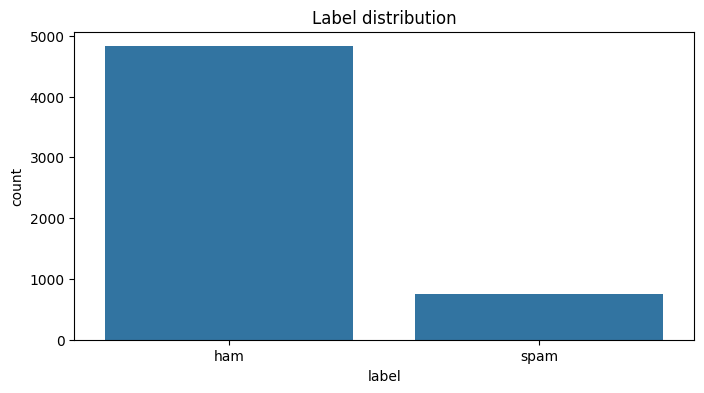

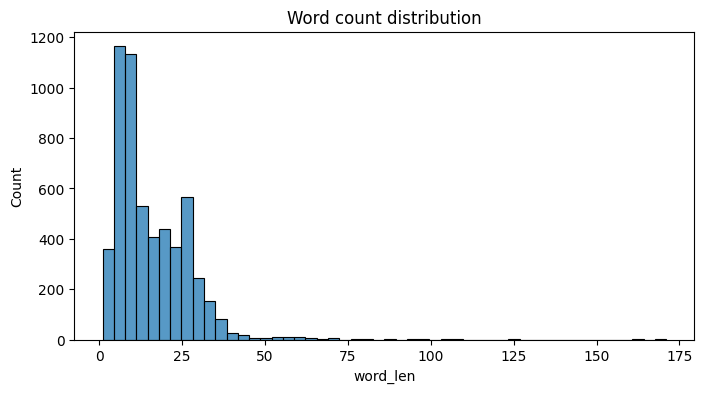

In [3]:
# Stage 3: Dataset analysis

analysis_df = df.copy()

missing_text = analysis_df["text"].isna().sum()
missing_label = analysis_df["label"].isna().sum()
empty_text = analysis_df["text"].astype(str).str.strip().eq("").sum()
duplicate_rows = analysis_df.duplicated().sum()
duplicate_texts = analysis_df.duplicated(subset=["text"]).sum()

analysis_df["char_len"] = analysis_df["text"].astype(str).str.len()
analysis_df["word_len"] = analysis_df["text"].astype(str).str.split().str.len()

print("DATASET SHAPE")
print(analysis_df.shape)
print()

print("FIRST 5 ROWS")
with pd.option_context("display.max_colwidth", 120):
    print(analysis_df[["label", "text"]].head(5).to_string(index=False))
print()

print("MISSING VALUES")
print(pd.Series({
    "missing_text": missing_text,
    "missing_label": missing_label,
    "empty_text": empty_text
}).to_string())
print()

print("DUPLICATES")
print(pd.Series({
    "duplicate_rows": duplicate_rows,
    "duplicate_texts": duplicate_texts
}).to_string())
print()

print("LABEL DISTRIBUTION")
label_stats = pd.DataFrame({
    "count": analysis_df["label"].value_counts(dropna=False),
    "pct": analysis_df["label"].value_counts(dropna=False, normalize=True).mul(100).round(2)
})
print(label_stats.to_string())
print()

print("TEXT LENGTH STATS OVERALL")
print(analysis_df[["char_len", "word_len"]].describe().round(2).to_string())
print()

print("TEXT LENGTH STATS BY LABEL")
by_label = analysis_df.groupby("label")[["char_len", "word_len"]].agg(["mean", "median", "min", "max"]).round(2)
print(by_label.to_string())
print()

plt.figure(figsize=(8, 4))
sns.countplot(data=analysis_df, x="label")
plt.title("Label distribution")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=analysis_df, x="word_len", bins=50)
plt.title("Word count distribution")
plt.show()

In [4]:
# Stage 4: Text preprocessing and dataset cleanup

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [token for token in text.split() if token not in STOP_WORDS]
    return " ".join(tokens)

work_df = df.copy()

print(f"Shape before cleanup: {work_df.shape}")

work_df = work_df.drop_duplicates().reset_index(drop=True)
work_df["clean_text"] = work_df["text"].apply(clean_text)
work_df = work_df[work_df["clean_text"].str.strip() != ""].reset_index(drop=True)
work_df["label_num"] = work_df["label"].map({"ham": 0, "spam": 1}).astype(int)

print(f"Shape after cleanup: {work_df.shape}")
print()
print("Label distribution after cleanup")
print(
    pd.DataFrame({
        "count": work_df["label"].value_counts(),
        "pct": work_df["label"].value_counts(normalize=True).mul(100).round(2)
    }).to_string()
)
print()
with pd.option_context("display.max_colwidth", 120):
    print(work_df[["label", "text", "clean_text"]].head(10).to_string(index=False))

Shape before cleanup: (5572, 2)
Shape after cleanup: (5162, 4)

Label distribution after cleanup
       count    pct
label              
ham     4509  87.35
spam     653  12.65

label                                                                                                                                                             text                                                                                                      clean_text
  ham                                                  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                              go jurong point crazy available bugis n great world la e buffet cine got amore wat
  ham                                                                                                                                    Ok lar... Joking wif u oni...                                                                                         ok lar jo

In [5]:
# Stage 5: Train validation split

X = work_df["clean_text"]
y = work_df["label_num"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
valid_df = pd.DataFrame({"text": X_valid, "label": y_valid})

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_valid)}")
print()

print("Train label distribution")
print(
    pd.DataFrame({
        "count": y_train.value_counts().sort_index(),
        "pct": y_train.value_counts(normalize=True).sort_index().mul(100).round(2)
    }, index=["ham", "spam"]).to_string()
)
print()

print("Validation label distribution")
print(
    pd.DataFrame({
        "count": y_valid.value_counts().sort_index(),
        "pct": y_valid.value_counts(normalize=True).sort_index().mul(100).round(2)
    }, index=["ham", "spam"]).to_string()
)

Train size: 4129
Validation size: 1033

Train label distribution
      count  pct
ham     NaN  NaN
spam    NaN  NaN

Validation label distribution
      count  pct
ham     NaN  NaN
spam    NaN  NaN


In [6]:
# Stage 6: BoW vectorization

bow_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_valid_bow = bow_vectorizer.transform(X_valid)

print(f"BoW train shape: {X_train_bow.shape}")
print(f"BoW valid shape: {X_valid_bow.shape}")

bow_features = bow_vectorizer.get_feature_names_out()
print("Sample BoW features:")
print(bow_features[:30])

BoW train shape: (4129, 5000)
BoW valid shape: (1033, 5000)
Sample BoW features:
['aah' 'abiola' 'able' 'abt' 'ac' 'acc' 'accept' 'access' 'accident'
 'accident claim' 'accidentally' 'account' 'account details'
 'account number' 'account statement' 'ache' 'acl' 'acl pm' 'across'
 'across sea' 'action' 'action custcare' 'activate' 'activities' 'actor'
 'actually' 'actually getting' 'actually send' 'ad' 'add']


In [7]:
# Stage 7: TF-IDF vectorization

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_valid_tfidf = tfidf_vectorizer.transform(X_valid)

print(f"TF-IDF train shape: {X_train_tfidf.shape}")
print(f"TF-IDF valid shape: {X_valid_tfidf.shape}")

tfidf_features = tfidf_vectorizer.get_feature_names_out()
print("Sample TF-IDF features:")
print(tfidf_features[:30])

TF-IDF train shape: (4129, 5000)
TF-IDF valid shape: (1033, 5000)
Sample TF-IDF features:
['aah' 'abiola' 'able' 'abt' 'ac' 'acc' 'accept' 'access' 'accident'
 'accident claim' 'accidentally' 'account' 'account details'
 'account number' 'account statement' 'ache' 'acl' 'acl pm' 'across'
 'across sea' 'action' 'action custcare' 'activate' 'activities' 'actor'
 'actually' 'actually getting' 'actually send' 'ad' 'add']


In [8]:
# Stage 8: Pretrained embeddings

%pip -q install gensim

import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-100")
embedding_dim = embedding_model.vector_size

def text_to_embedding(text: str, model, dim: int) -> np.ndarray:
    tokens = text.split()
    vectors = [model[token] for token in tokens if token in model]
    if not vectors:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vectors, axis=0).astype(np.float32)

X_train_emb = np.vstack([text_to_embedding(text, embedding_model, embedding_dim) for text in X_train])
X_valid_emb = np.vstack([text_to_embedding(text, embedding_model, embedding_dim) for text in X_valid])

print(f"Embedding dimension: {embedding_dim}")
print(f"Embedding train shape: {X_train_emb.shape}")
print(f"Embedding valid shape: {X_valid_emb.shape}")

non_zero_train = np.mean(np.linalg.norm(X_train_emb, axis=1) > 0)
non_zero_valid = np.mean(np.linalg.norm(X_valid_emb, axis=1) > 0)

print(f"Non-zero train vectors: {non_zero_train:.4f}")
print(f"Non-zero valid vectors: {non_zero_valid:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 111.1 MB/s eta 0:00:00
[==================================================] 100.0% 128.1/128.1MB downloaded
Embedding dimension: 100
Embedding train shape: (4129, 100)
Embedding valid shape: (1033, 100)
Non-zero train vectors: 0.9993
Non-zero valid vectors: 0.9961


In [9]:
# Stage 9: Model training

bow_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
bow_model.fit(X_train_bow, y_train)

tfidf_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
tfidf_model.fit(X_train_tfidf, y_train)

emb_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
emb_model.fit(X_train_emb, y_train)

print("Models trained successfully")

Models trained successfully


In [10]:
# Stage 10: Evaluation

def evaluate_model(model, X_train_data, X_valid_data, y_train_true, y_valid_true, model_name: str):
    train_pred = model.predict(X_train_data)
    valid_pred = model.predict(X_valid_data)

    train_proba = model.predict_proba(X_train_data)[:, 1]
    valid_proba = model.predict_proba(X_valid_data)[:, 1]

    train_accuracy = accuracy_score(y_train_true, train_pred)
    valid_accuracy = accuracy_score(y_valid_true, valid_pred)

    train_auc = roc_auc_score(y_train_true, train_proba)
    valid_auc = roc_auc_score(y_valid_true, valid_proba)

    print(f"=== {model_name} ===")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {valid_accuracy:.4f}")
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Validation AUC: {valid_auc:.4f}")
    print()
    print("Classification report")
    print(classification_report(y_valid_true, valid_pred, target_names=["ham", "spam"]))
    print("Confusion matrix")
    print(confusion_matrix(y_valid_true, valid_pred))
    print()

    return {
        "model": model_name,
        "train_accuracy": train_accuracy,
        "valid_accuracy": valid_accuracy,
        "train_auc": train_auc,
        "valid_auc": valid_auc
    }

results = []

results.append(
    evaluate_model(
        bow_model,
        X_train_bow,
        X_valid_bow,
        y_train,
        y_valid,
        "BoW + LogisticRegression"
    )
)

results.append(
    evaluate_model(
        tfidf_model,
        X_train_tfidf,
        X_valid_tfidf,
        y_train,
        y_valid,
        "TF-IDF + LogisticRegression"
    )
)

results.append(
    evaluate_model(
        emb_model,
        X_train_emb,
        X_valid_emb,
        y_train,
        y_valid,
        "GloVe Avg + LogisticRegression"
    )
)

results_df = pd.DataFrame(results).sort_values(by=["valid_auc", "valid_accuracy"], ascending=False).reset_index(drop=True)

print("Summary")
print(results_df.to_string(index=False))

=== BoW + LogisticRegression ===
Train Accuracy: 0.9978
Validation Accuracy: 0.9826
Train AUC: 1.0000
Validation AUC: 0.9913

Classification report
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       902
        spam       0.95      0.91      0.93       131

    accuracy                           0.98      1033
   macro avg       0.97      0.95      0.96      1033
weighted avg       0.98      0.98      0.98      1033

Confusion matrix
[[896   6]
 [ 12 119]]

=== TF-IDF + LogisticRegression ===
Train Accuracy: 0.9857
Validation Accuracy: 0.9748
Train AUC: 0.9985
Validation AUC: 0.9937

Classification report
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       902
        spam       0.88      0.92      0.90       131

    accuracy                           0.97      1033
   macro avg       0.94      0.95      0.94      1033
weighted avg       0.98      0.97      0.98      1033

Confus

In [12]:
# Stage 11: Result interpretation

best_model_name = results_df.iloc[0]["model"]
best_valid_accuracy = results_df.iloc[0]["valid_accuracy"]
best_valid_auc = results_df.iloc[0]["valid_auc"]

print(f"Best model: {best_model_name}")
print(f"Best validation Accuracy: {best_valid_accuracy:.4f}")
print(f"Best validation AUC: {best_valid_auc:.4f}")
print()


Best model: TF-IDF + LogisticRegression
Best validation Accuracy: 0.9748
Best validation AUC: 0.9937



# Висновки

## Найкраща модель

* TF-IDF + LogisticRegression — найкраща модель за AUC = 0.9937, тобто за якістю ранжування ймовірностей;
* BoW + LogisticRegression — найкраща модель за Accuracy = 0.9826 і фактично краща на фіксованому порозі класифікації 0.5;
* GloVe Avg + LogisticRegression — помітно слабша за sparse-підходи на цій задачі.

## Оцінка моделей

Для оцінки моделей були використані метрики Accuracy та ROC-AUC.

### Чому саме ці метрики:

* Accuracy показує загальну частку правильних передбачень і є простою для інтерпретації.
* ROC-AUC є особливо корисною для цієї задачі, оскільки датасет є незбалансованим: частка класу ham значно більша за частку spam. Метрика AUC оцінює, наскільки добре модель відокремлює два класи незалежно від конкретного порогу класифікації.


| Model                          | Train Accuracy | Validation Accuracy | Train AUC | Validation AUC |
| ------------------------------ | -------------: | ------------------: | --------: | -------------: |
| BoW + LogisticRegression       |         0.9978 |              0.9826 |    1.0000 |         0.9913 |
| TF-IDF + LogisticRegression    |         0.9857 |              0.9748 |    0.9985 |         0.9937 |
| GloVe Avg + LogisticRegression |         0.9145 |              0.9022 |    0.9673 |         0.9700 |


#### Додатково для класу spam:

* BoW: precision = 0.95, recall = 0.91, F1 = 0.93
* TF-IDF: precision = 0.88, recall = 0.92, F1 = 0.90
* GloVe Avg: precision = 0.57, recall = 0.95, F1 = 0.71

## Аналіз та інтерпретація результатів

### Найкраща модель

Результати показують, що найкращою моделлю за метрикою ROC-AUC є TF-IDF + LogisticRegression з показником 0.9937 на валідаційній вибірці. Це означає, що саме ця модель найкраще відокремлює спам від легітимних повідомлень у термінах ймовірнісного ранжування.

Водночас, якщо оцінювати моделі за Accuracy та якістю класифікації при стандартному порозі, то BoW + LogisticRegression демонструє дещо кращий практичний результат:

* вища Accuracy: 0.9826 проти 0.9748;
* вищий F1 для класу spam: 0.93 проти 0.90;
* менше загальних помилок на валідаційній вибірці.

Отже, висновок залежить від того, яку метрику вважати основною:

* якщо основна метрика — ROC-AUC, то кращою є TF-IDF;
* якщо важливіша якість фінальної бінарної класифікації на поточному порозі, то кращим виглядає BoW.

### Переваги та недоліки підходів

#### BoW

* Переваги: простий, ефективний, добре працює на задачах на кшталт spam detection, де важливі конкретні слова та фрази.
* Недоліки: не враховує семантичну близькість слів, сильно залежить від частотності конкретних токенів.

#### TF-IDF

* Переваги: зменшує вагу надто частих слів, краще виділяє інформативні ознаки, показав найкращий ROC-AUC.
* Недоліки: також не враховує повноцінний контекст і порядок слів, як і BoW, залишається sparse-поданням.

### Попередньо навчені ембединги (GloVe average)

* Переваги: дають щільне векторне представлення, краще передають загальну семантику тексту.
* Недоліки: усереднення векторів слів втрачає порядок слів і локальні spam-ознаки; у цій задачі такий підхід спрацював гірше за BoW/TF-IDF.

### Узагальнення

Для даного датасету найефективнішими виявилися класичні sparse-підходи — BoW і TF-IDF. Це логічно, оскільки задача виявлення спаму сильно залежить від наявності характерних слів, шаблонів і коротких фраз. Усереднені попередньо навчені ембединги в цьому випадку втрачають частину важливої інформації, тому поступаються класичним методам.

## Фінальний висновок

У задачі класифікації спаму найкращі результати показали моделі на основі BoW та TF-IDF. За метрикою ROC-AUC найкращою є модель TF-IDF + LogisticRegression, а за Accuracy та якістю класифікації класу spam при стандартному порозі трохи кращою виявилась BoW + LogisticRegression. Підхід із попередньо навченими ембедингами GloVe Average показав нижчу якість, що пояснюється втратою важливих локальних текстових ознак під час усереднення векторів слів.